License and source:

[opencv-object-tracking](https://broutonlab.com/blog/opencv-object-tracking/)

[OpenCV free course](https://opencv.org/opencv-free-course/)

[Maktabkhooneh](https://maktabkhooneh.org/course/%d8%a2%d9%85%d9%88%d8%b2%d8%b4-%d9%be%d8%b1%d8%af%d8%a7%d8%b2%d8%b4-%d8%aa%d8%b5%d9%88%db%8c%d8%b1-%d8%a8%db%8c%d9%86%d8%a7%db%8c%db%8c-%d9%85%d8%a7%d8%b4%db%8c%d9%86-opencv-mk1664/)

**Libraries and Packages**

In [1]:
import cv2
import os
import matplotlib.pyplot as plt
from IPython.display import HTML

**Global Variables and Functions**

In [2]:
video_input_file_name = "videos/race_car.mp4"

In [3]:
def drawRectangle(frame, bbox):
    '''This function will draw a bounding box over tracking object at the given current frame with given bbox coordinates.
    '''
    p1 = (int(bbox[0]), int(bbox[1]))
    p2 = (int(bbox[0] + bbox[2]), int(bbox[1] + bbox[3]))
    cv2.rectangle(frame, p1, p2, (255,0,0), 2, 1)

In [4]:
def displayRectangle(frame, bbox):
    '''This function will show the drawn bounding box over current frame'''
    plt.figure(figsize=(20,10))
    frameCopy = frame.copy()
    drawRectangle(frameCopy, bbox)
    frameCopy = cv2.cvtColor(frameCopy, cv2.COLOR_RGB2BGR)
    plt.imshow(frameCopy); plt.axis('off')    

## Multiple Instance Learning Tracker

MIL Tracker has the same approach as BOOSTING, however, instead of guessing where the tracked object is in the next frame, an approach is used in which several potentially positive objects, called a “bag”, are selected around a positive definite object. A positive “bag” contains at least one positive result.

In [5]:
tracker = cv2.TrackerMIL_create()

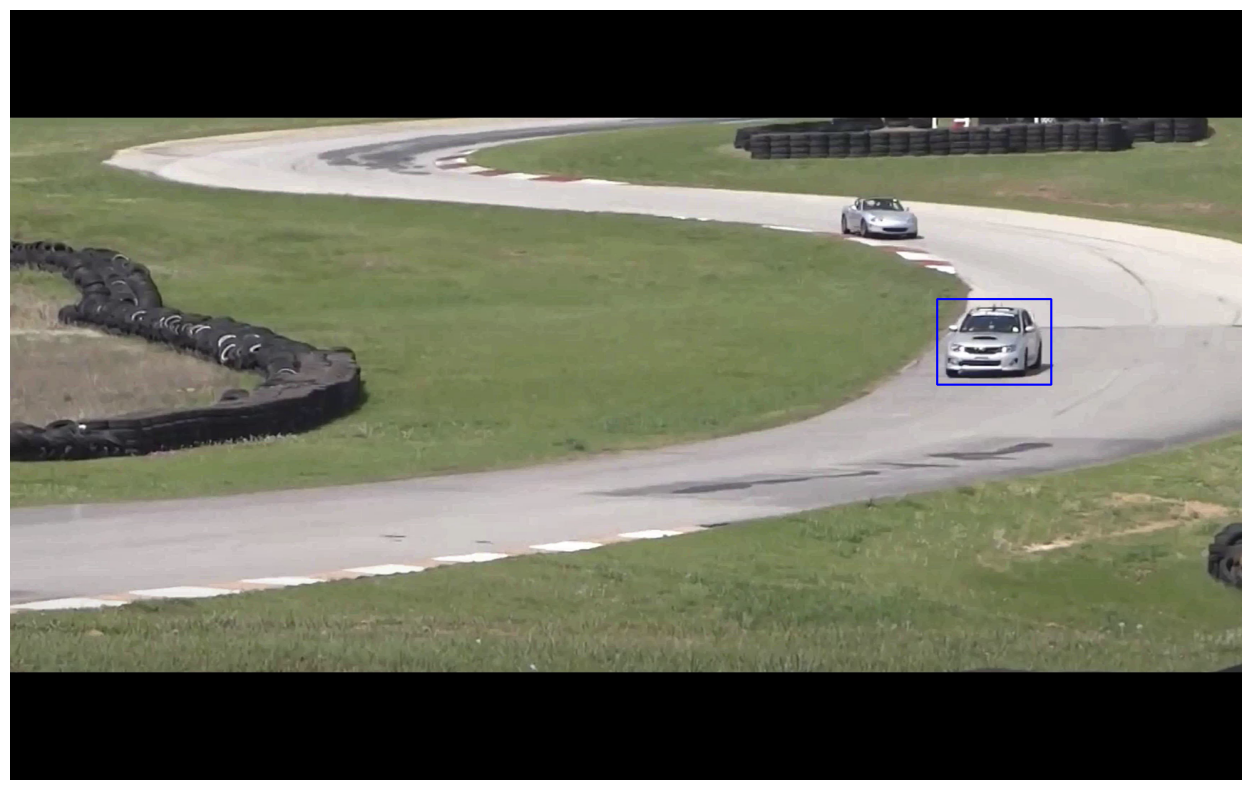

In [9]:
#Read video for boosting
video = cv2.VideoCapture(video_input_file_name)
ret, frame = video.read()

if not video.isOpened():
    print("Could not open video ...")
else : 
    width = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))

video_output_file_name = 'race_car-' + "MIL Tracker" + '.mp4'
video_out = cv2.VideoWriter(video_output_file_name,cv2.VideoWriter_fourcc(*'avc1'), 10, (width, height))

# Define a bounding box for tracking the object
bbox = (1300, 405, 160, 120)
displayRectangle(frame,bbox)

In [10]:
# Initialize tracker with first frame and bounding box
tracker.init(frame, bbox)

In [11]:
#Run object tracking over captured video
while True:
    ret, frame = video.read()
    if not ret:
        break 
    
    # Start timer for comparison between available algorithms
    tm = cv2.TickMeter()

    tm.start()
    ret, bbox = tracker.update(frame)
    tm.stop()
    # Draw the bounding box using found new coords of object
    if ret:
        drawRectangle(frame, bbox)
    else :
        #We lost the object! that is the disaster
        cv2.putText(frame, "Tracking failure detected", (80,140), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 3)

    # Display useful information like tracker's name and fps rate
    cv2.putText(frame, "MIL" + " Tracker", (80,60), cv2.FONT_HERSHEY_SIMPLEX, 1, (50, 170, 50), 3)
    cv2.putText(frame, "FPS : " + str(tm.getFPS()), (80,100), cv2.FONT_HERSHEY_SIMPLEX, 1, (50, 170, 50), 3)

    # Write frame to video for saving result
    video_out.write(frame)
    
video.release()
video_out.release()

In [12]:
#Demonstrate the final result using HTML function
HTML(f"""
<video width=1024 controls>
  <source src="{video_output_file_name}" type="video/mp4">
</video>
""")